# NLP C8 — Phân tích attention của BERT

Notebook này minh họa cách tải mô hình **BERT**, mã hóa một câu đầu vào, lấy ma trận **attention** từ mô hình và trực quan hóa nó bằng heatmap.

## Mục tiêu của notebook

- Tải tokenizer và mô hình `bert-base-uncased`.
- Mã hóa câu đầu vào thành tensor.
- Chạy mô hình ở chế độ suy luận để lấy attention.
- Chọn một layer và một head cụ thể.
- Vẽ heatmap attention để quan sát mối liên hệ giữa các token.

## 1. Import thư viện

Phần này nạp các thư viện cần thiết cho xử lý tensor, vẽ biểu đồ và dùng mô hình BERT từ Hugging Face.

In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel

## 2. Tải tokenizer và mô hình

Tokenizer chuyển văn bản thành token id. Mô hình BERT được tải với `output_attentions=True` để trả về attention của từng lớp.

In [2]:
# Load model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Chuẩn bị câu đầu vào

Ở đây notebook dùng một câu mẫu đơn giản để kiểm tra attention của mô hình.

In [3]:
# Input câu
sentence = "i love you"

## 4. Mã hóa câu thành tensor

Tokenizer chuyển câu thành các chỉ số token để đưa vào mô hình.

In [4]:
# Encode
inputs = tokenizer(sentence, return_tensors="pt")

## 5. Chạy mô hình để lấy đầu ra

`torch.no_grad()` được dùng vì đây là bước suy luận, không cần tính gradient.

In [5]:
# Forward
with torch.no_grad():
    outputs = model(**inputs)

## 6. Trích xuất attention

`outputs.attentions` là danh sách attention của từng layer. Mỗi phần tử có dạng `(batch, head, token, token)`.

In [6]:
# Lấy attention
attentions = outputs.attentions  # (layer, batch, head, token, token)

## 7. Chọn layer và head để quan sát

Notebook lấy một layer và một head cụ thể rồi chuyển attention sang mảng NumPy để tiện vẽ.

In [7]:
# Chọn layer + head
layer = 0
head = 0
attention = attentions[layer][0, head].numpy()

## 8. Lấy nhãn token

Mỗi token được hiển thị trên trục của heatmap để dễ đọc kết quả.

In [8]:
# Token labels
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

## 9. Vẽ heatmap attention

Biểu đồ này cho thấy mỗi token đang chú ý đến token nào trong câu đầu vào.

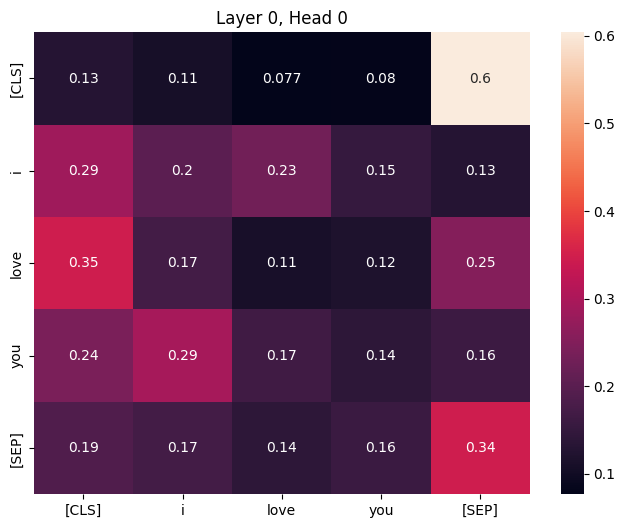

In [9]:
# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, annot=True)
plt.title(f"Layer {layer}, Head {head}")
plt.show()